# Sesión 2 Laboratorio de Computación Cuántica 1

## Introducción a Qiskit

En la sesión de hoy nos concentraremos en dar una introducción de los conceptos básicos de Qiskit, con la intención de estar preparados para las próximas sesiones y programar las cosas.

Todo el contenido se manejará principalmente en Colab. Si deseas ejecutarlo localmente, sólo necesitas una instalación de Python y un editor compatible con notebooks, como Visual Studio Code o Jupyter. A continuación veremos cómo aislar las dependencias del curso mediante un entorno virtual.

## ¿Qué es Qiskit?
Qiskit es un framework de software open-source para el desarrollo de algoritmos de computación cuántica. Proporciona herramientas para construir, manipular y ejecutar circuitos cuánticos, así como para simularlos clásicamente o ejecutarlos en hardware cuántico real a través de servicios en la nube.

En esta sesión voy a dar las herramientas básicas para manipular Qiskit. Probablemente los chicos que ya hayan llevado Computación Cuántica 1 ya estén familiarizados con todo lo que se va a mostrar aquí; sin embargo, buscamos que todos estén en la misma página y podamos avanzar con el resto del contenido del curso.

In [1]:
# Para instalar Qiskit en tu entorno de Colab, puedes ejecutar esta celda
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Primeros pasos: crear un circuito cuántico

Un qubit es una entidad matemática de la forma $|\psi\rangle = \alpha|e_0\rangle+\beta|e_1\rangle$, con $|\alpha|^2+|\beta|^2=1$, donde $|e_i\rangle$ es un elemento de una base del espacio $\mathbb{C}^2$.

$\bullet$ Compuertas. Nos permiten evolucionar el sistema. Están representadas por operadores unitarios (operadores cuyo adjunto hermitiano es su inverso). Las principales son:

>$\star$ Hadamard: $\quad\hat H=\tfrac{1}{\sqrt{2}}\big(|0\rangle\langle0|+|0\rangle\langle1|+|1 \rangle\langle0|-|1\rangle\langle1|\big)$.  

>$\star$ Pauli-$z$: $\quad\hat z = |0\rangle\langle0|-|1\rangle\langle1|$

>$\star$ Pauli-$x$: $\quad\hat x = |0\rangle\langle1|+|1\rangle\langle0|$

>$\star$ Pauli-$y$: $\quad\hat y = -i|0\rangle\langle1|+i|1\rangle\langle0|$

>$\star$ Control-NOT: $\quad\mathrm{CNOT}
\;=\;
|0\rangle\langle 0| \otimes I
\;+\;
|1\rangle\langle 1| \otimes X$



Vamos a fabricar un circuito en donde apliquemos estos operadores a un sistema cuántico y vamos a visualizarlo. Al ejecutar un circuito sin una inicialización explícita, Qiskit parte del estado $|0\cdots0\rangle$.

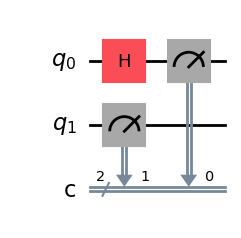

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

# Crear registros
qr = QuantumRegister(2, name='q')
cr = ClassicalRegister(2, name='c')

# Crear circuito cuántico
qc = QuantumCircuit(qr, cr)

# Aplicar compuertas de un solo qubit

qc.h(qr[0])


# Medición
qc.measure(qr, cr)


# Mostrar el circuito
qc.draw('mpl')  # Esto permite dibujar el circuito utilizando Matplotlib

Este es un ejemplo de un circuito de 2 qubits. Es importante distinguir las convenciones de orden de Qiskit: en el diagrama, el qubit 0 aparece arriba; en las cadenas de bits y etiquetas de estados, el bit 0 aparece a la derecha porque es el menos significativo. Por ejemplo, `01` significa que $q_1=0$ y $q_0=1$.

Para ejecutar los circuitos que ya realizamos, utilizaremos un *backend*, que representa el destino de ejecución y puede ser un simulador o un dispositivo cuántico. En esta sesión usaremos un simulador para observar la distribución de resultados de nuestro circuito.

Qiskit Aer es el paquete encargado de la simulación clásica de circuitos cuánticos.
Su función es permitirnos ejecutar un circuito cuántico en una computadora clásica, sin necesidad de hardware cuántico real.

In [3]:
from qiskit_aer import AerSimulator

# 1. Creamos un simulador cuántico
backend = AerSimulator()

# 2. Ejecutamos el circuito cuántico
#    shots indica cuántas veces repetimos el experimento
job = backend.run(qc, shots=100)

# 3. Obtenemos los resultados de la simulación
resultados = job.result()

# 4. Extraemos los conteos de medición
counts = resultados.get_counts()

# Mostramos los resultados
counts


{'00': 56, '01': 44}

También podemos visualizarlos en un histograma con el módulo `qiskit.visualization`.

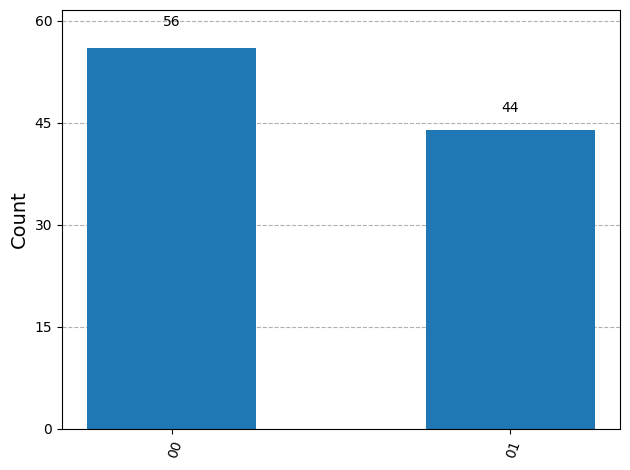

In [4]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

A partir de ahora, con las bases claras, vamos a trabajar en códigos donde aplicaremos desde cero lo que ya sabemos, con la intención de aprender a manejar Qiskit con soltura.

Aquí, `QuantumCircuit(1)` crea directamente el registro cuántico y `measure_all()` añade el registro clásico necesario.

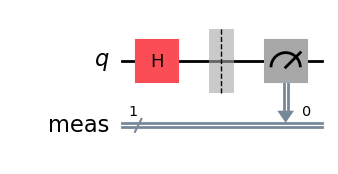

In [5]:
from qiskit import QuantumCircuit

# 1. Creamos un circuito cuántico con 1 qubit
#    No definimos registros clásicos explícitamente
circuito_hadamard = QuantumCircuit(1)

# 2. Aplicamos la compuerta Hadamard al qubit 0
#    Esto crea una superposición cuántica
circuito_hadamard.h(0)

# 3. Medimos todos los qubits del circuito
#    Qiskit crea automáticamente un registro clásico
circuito_hadamard.measure_all()

# 4. Dibujamos el circuito
circuito_hadamard.draw('mpl')


Viendo el circuito, ¿qué estado se preparó y qué esperas medir con la simulación? Usaremos el mismo backend que antes.

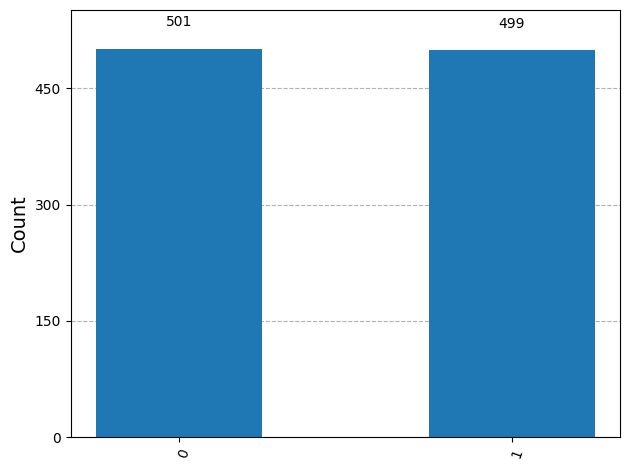

In [6]:
job = backend.run(circuito_hadamard, shots=1000)

resultados = job.result()
counts = resultados.get_counts()
plot_histogram(counts)

Ejercicio 1: Cambia UNA SOLA LETRA del código anterior para que la medición siempre dé 1.

Ejercicio 2: Si aplicas una compuerta Z al estado $|0\rangle$ en lugar de una Hadamard, ¿qué resultado obtienes en la simulación? ¿Por qué?

Ejercicio 3: Aplica una compuerta Z sobre el qubit después de la compuerta Hadamard y finaliza aplicando una última compuerta Hadamard. ¿Cuál es tu predicción de lo que vas a medir? ¿Esta predicción fue acertada?

$H|0⟩=\frac{1}{\sqrt{2}}(|0⟩+|1⟩)=|+⟩$


$\hat{Z}H|0⟩=\frac{1}{\sqrt{2}}(|0⟩-|1⟩)=|-⟩$

$\hat{H}\hat{Z}H|0⟩=|1⟩$


## Esfera de Bloch

En computación cuántica, los estados de un solo qubit tienen una representación matemática clara. Esta representación está dada por la expresión

$$|\psi\rangle=\alpha |0\rangle + \beta |1\rangle$$

donde $\alpha$ y $\beta$ son números complejos que cumplen la condición de normalización: $|\alpha|^2+|\beta|^2=1$. Para ello existe una forma gráfica de representar esto: la esfera de Bloch. Cualquier estado de un qubit puede representarse como un punto sobre ella.

Inicialmente, si suponemos $\alpha=a+bi$ y $\beta=c+di$, podríamos pensar que el estado cuántico tiene 4 grados de libertad, pero no es el caso ni mucho menos. Existen 2 condiciones que impiden esto:

- La condición de normalización, que se puede reexpresar como $a^2+b^2+c^2+d^2=1$.
- La condición de la fase global, que dice que todo estado $|\psi\rangle$ es físicamente idéntico a cualquier estado $e^{i\gamma}|\psi\rangle$. Por ejemplo, el estado $\frac{1}{\sqrt{2}}(|0\rangle+i|1\rangle)$ es idéntico al estado $\frac{1}{\sqrt{2}}(i|0\rangle-|1\rangle)$. ¿Por qué?

Esto nos dice que, al final, el sistema cuántico tiene en realidad 2 grados físicos de libertad. La fase global no genera un estado físico diferente. Llamaremos a estos 2 parámetros $(\theta,\phi)$.

El estado entonces queda de la siguiente manera:

$$|\psi\rangle=\cos(\frac{\theta}{2})|0\rangle +e^{i\phi}\sin(\frac{\theta}{2}) |1\rangle$$

Y le llamaremos vector de Bloch a $r=(\sin\theta \cos\phi, \sin\theta \sin \phi, \cos \theta)$.

### Representación de estados en Qiskit

En Qiskit, un Statevector de un qubit se escribe como una lista con el orden $[\alpha,\beta]$: la primera entrada es la amplitud de $|0\rangle$ y la segunda es la amplitud de $|1\rangle$. Por lo tanto, podemos construir directamente cualquier punto de la esfera usando:

    Statevector([
        np.cos(theta / 2),
        np.exp(1j * phi) * np.sin(theta / 2)
    ])

Algunos estados importantes corresponden a los siguientes ángulos:

- $|0\rangle$: $\theta=0$, $\phi=0$. Se encuentra en el polo norte.
- $|1\rangle$: $\theta=\pi$, $\phi=0$. Se encuentra en el polo sur.
- $|+\rangle$: $\theta=\pi/2$, $\phi=0$. Se encuentra sobre el eje $+x$.
- $|-\rangle$: $\theta=\pi/2$, $\phi=\pi$. Se encuentra sobre el eje $-x$.
- $|+i\rangle$: $\theta=\pi/2$, $\phi=\pi/2$. Se encuentra sobre el eje $+y$.
- $|-i\rangle$: $\theta=\pi/2$, $\phi=-\pi/2$. Se encuentra sobre el eje $-y$.

También podemos preparar el estado mediante un circuito. La compuerta RY(theta) fija el ángulo polar $\theta$ y después RZ(phi) fija el ángulo azimutal $\phi$. El vector de estado puede diferir por una fase global, pero representa el mismo punto físico sobre la esfera.

|0⟩ = [1.+0.j 0.+0.j]


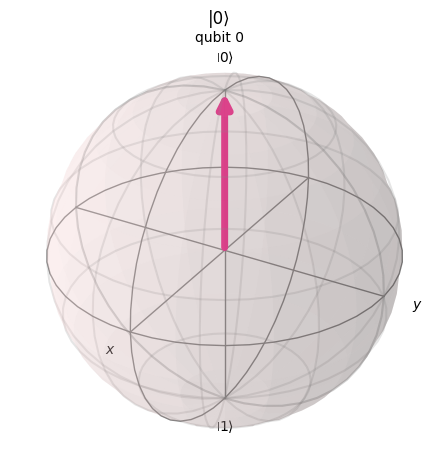

|1⟩ = [0.+0.j 1.+0.j]


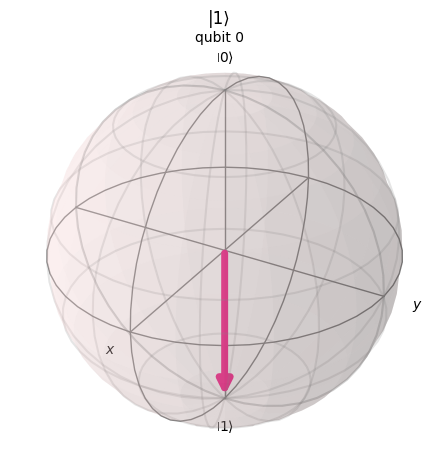

|+⟩ = [0.707+0.j 0.707+0.j]


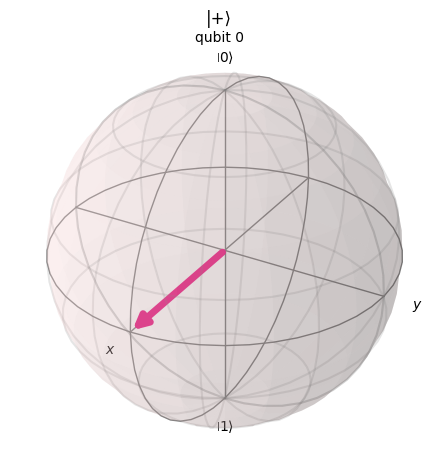

|-⟩ = [ 0.707+0.j -0.707+0.j]


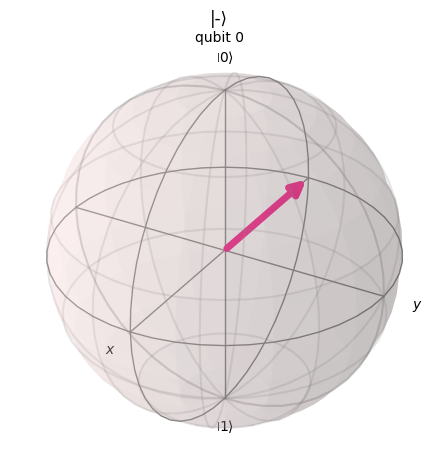

|+i⟩ = [0.707+0.j    0.   +0.707j]


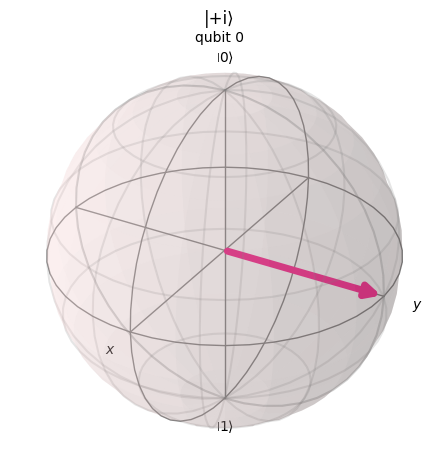

|-i⟩ = [0.707+0.j    0.   -0.707j]


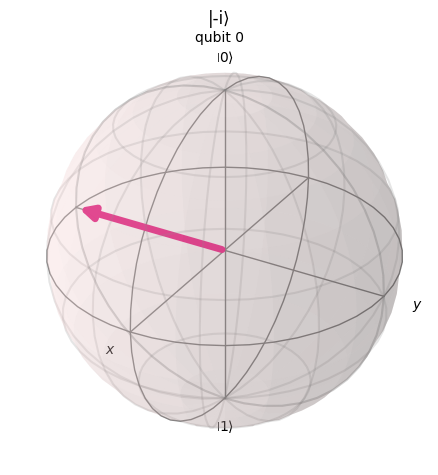

In [7]:
import numpy as np  # Importamos NumPy para trabajar con ángulos y números complejos
from IPython.display import display  # Importamos display para mostrar varias figuras
from qiskit.quantum_info import Statevector  # Importamos la representación vectorial de un estado
from qiskit.visualization import plot_bloch_multivector  # Importamos la visualización de la esfera de Bloch

def estado_bloch(theta, phi):  # Construimos un estado a partir de sus dos ángulos
    return Statevector([
        np.cos(theta / 2),  # Amplitud del estado |0⟩
        np.exp(1j * phi) * np.sin(theta / 2),  # Amplitud del estado |1⟩
    ])

estados_bloch = {  # Relacionamos cada estado conocido con sus ángulos theta y phi
    "|0⟩": estado_bloch(0, 0),
    "|1⟩": estado_bloch(np.pi, 0),
    "|+⟩": estado_bloch(np.pi / 2, 0),
    "|-⟩": estado_bloch(np.pi / 2, np.pi),
    "|+i⟩": estado_bloch(np.pi / 2, np.pi / 2),
    "|-i⟩": estado_bloch(np.pi / 2, -np.pi / 2),
}

for nombre, estado in estados_bloch.items():  # Recorremos y visualizamos todos los estados
    print(nombre, "=", np.round(estado.data, 3))  # Mostramos las amplitudes alfa y beta redondeadas
    figura = plot_bloch_multivector(estado)  # Colocamos el estado sobre la esfera de Bloch
    figura.suptitle(nombre)  # Añadimos el nombre del estado a la figura
    display(figura)  # Mostramos la figura en el notebook

[0.866+0.j    0.354+0.354j]
[0.8  -0.331j 0.462+0.191j]
True


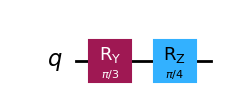

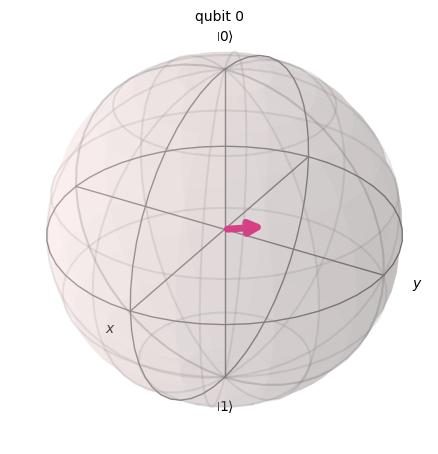

In [8]:
theta = np.pi / 3  # Elegimos el ángulo polar
phi = np.pi / 4  # Elegimos el ángulo azimutal

circuito_bloch = QuantumCircuit(1)  # Creamos un circuito de un qubit
circuito_bloch.ry(theta, 0)  # Movemos el estado desde el polo norte al ángulo theta
circuito_bloch.rz(phi, 0)  # Rotamos el estado alrededor del eje z hasta el ángulo phi

estado_desde_formula = estado_bloch(theta, phi)  # Construimos el estado usando las amplitudes
estado_desde_circuito = Statevector.from_instruction(circuito_bloch)  # Recuperamos el estado preparado por el circuito

print(np.round(estado_desde_formula.data, 3))  # Mostramos el estado construido con theta y phi
print(np.round(estado_desde_circuito.data, 3))  # Mostramos el estado construido con RY y RZ
print(estado_desde_formula.equiv(estado_desde_circuito))  # Comprobamos que son equivalentes salvo una fase global

display(circuito_bloch.draw("mpl"))  # Dibujamos el circuito de preparación
plot_bloch_multivector(estado_desde_circuito)  # Visualizamos el estado preparado

## Diferentes resultados de un circuito cuántico

Hasta ahora hemos ejecutado circuitos y recuperado conteos, pero cuando trabajamos con simuladores podemos recuperar información del circuito de diferentes maneras.

Vamos a separar tres resultados importantes:

1. **Vector de estado:** contiene las amplitudes complejas del estado cuántico.
2. **Probabilidades:** se obtienen tomando el valor absoluto al cuadrado de cada amplitud.
3. **Conteos:** indican cuántas veces apareció cada resultado después de repetir la medición una cantidad determinada de *shots*.

Para una compuerta Hadamard aplicada sobre $|0\rangle$ tenemos:

$$
H|0\rangle=\frac{1}{\sqrt{2}}\left(|0\rangle+|1\rangle\right).
$$

Por lo tanto, las probabilidades son:

$$
P(0)=\frac{1}{2},\qquad P(1)=\frac{1}{2}.
$$

Si ejecutamos solamente 100 *shots*, los conteos no tienen que ser exactamente 50 y 50. Los conteos se aproximan a las probabilidades y pueden cambiar entre ejecuciones.

Vector de estado: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Probabilidades: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
Conteos con 100 shots: {'0': 49, '1': 51}
Conteos con 1000 shots: {'0': 514, '1': 486}


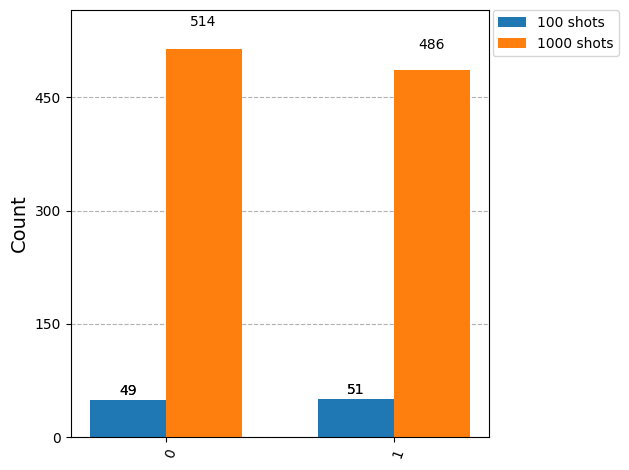

In [9]:
from qiskit.quantum_info import Statevector  # Importamos la clase para calcular el estado cuántico exacto

circuito_resultados = QuantumCircuit(1)  # Creamos un circuito cuántico de un qubit
circuito_resultados.h(0)  # Aplicamos Hadamard para preparar el estado |+⟩

estado_resultados = Statevector.from_instruction(circuito_resultados)  # Obtenemos las amplitudes del estado sin medirlo
probabilidades = estado_resultados.probabilities_dict()  # Convertimos las amplitudes en probabilidades exactas

circuito_medido = circuito_resultados.copy()  # Copiamos el circuito para conservar la versión sin mediciones
circuito_medido.measure_all()  # Añadimos un registro clásico y medimos todos los qubits

conteos_100 = backend.run(  # Ejecutamos el circuito medido en el simulador
    circuito_medido, shots=100, seed_simulator=42  # Repetimos el experimento 100 veces con una semilla fija
).result().get_counts()  # Recuperamos cuántas veces apareció cada resultado

conteos_1000 = backend.run(  # Ejecutamos nuevamente el mismo circuito
    circuito_medido, shots=1000, seed_simulator=42  # Repetimos el experimento 1000 veces con la misma semilla
).result().get_counts()  # Recuperamos los conteos de la segunda ejecución

print("Vector de estado:", estado_resultados)  # Mostramos las amplitudes complejas
print("Probabilidades:", probabilidades)  # Mostramos las probabilidades teóricas
print("Conteos con 100 shots:", conteos_100)  # Mostramos la muestra de 100 mediciones
print("Conteos con 1000 shots:", conteos_1000)  # Mostramos la muestra de 1000 mediciones

plot_histogram(  # Comparamos visualmente las dos distribuciones de resultados
    [conteos_100, conteos_1000],  # Entregamos ambos conjuntos de conteos
    legend=["100 shots", "1000 shots"]  # Identificamos cada ejecución en la gráfica
)

Ahora vamos a fabricar estados de Bell. ¿Recuerdas cuáles son?

$|\Phi^{+}\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right)$


$|\Phi^{-}\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle - |11\rangle\right)$


$|\Psi^{+}\rangle = \frac{1}{\sqrt{2}}\left(|01\rangle + |10\rangle\right)$

$|\Psi^{-}\rangle = \frac{1}{\sqrt{2}}\left(|01\rangle - |10\rangle\right)$

Te daré el circuito para los estados $|\Phi^{+}\rangle$ y $|\Psi^{+}\rangle$. Tú tendrás que fabricar los estados negativos en Qiskit.

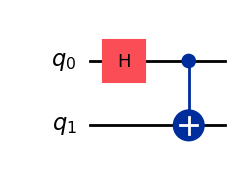

In [11]:
from qiskit.quantum_info import Statevector

phimas=QuantumCircuit(2)
phimas.h(0)
phimas.cx(0,1)
phimas.draw('mpl')

In [12]:
state = Statevector.from_instruction(phimas)

# Mostramos el statevector
state

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


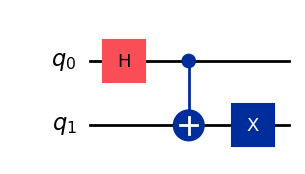

In [13]:
psimas=QuantumCircuit(2)
psimas.h(0)
psimas.cx(0,1)
psimas.x(1)
psimas.draw('mpl')

In [14]:
state = Statevector.from_instruction(psimas)

# Mostramos el statevector
state

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


## Observables y valores esperados

Antes de avanzar, hay que hacer un paréntesis conceptual que no he explicado antes: los valores esperados de un operador.

En mecánica cuántica, tú no observas algo, tú visualizas el efecto de un valor físico del estado en un medidor. Las cantidades físicas se les denomina "Observables" y son operadores Hermitianos que representan una cantidad física. En computación cuántica, cuando tú mides, tú lo que haces en realidad es correr el observable $\hat{Z}$ sobre el sistema. El valor esperado de un sistema está dado por:

\begin{equation}
    \langle\psi|\hat{Z}|\psi\rangle
\end{equation}

y dado que por el teorema de descomposición espectral, todo operador hermitiano se puede ver como la suma de los proyectores de sus eigenvectores multiplicados con sus eigenvalores

\begin{equation}
    \hat{Z}=\sum_i \lambda_i |\lambda_i\rangle\langle\lambda_i|
\end{equation}

Probabilidades en base computacional
$$
P(0)=\left|\cos\left(\frac{\theta}{2}\right)\right|^2=\cos^2\left(\frac{\theta}{2}\right),
\qquad
P(1)=\left|-i\sin\left(\frac{\theta}{2}\right)\right|^2=\sin^2\left(\frac{\theta}{2}\right)
$$

Valor esperado de Z
$$
\langle Z\rangle = P(0)-P(1)
= \cos^2\left(\frac{\theta}{2}\right)-\sin^2\left(\frac{\theta}{2}\right)
= \cos(\theta)
$$

In [15]:
from qiskit.quantum_info import SparsePauliOp

theta = np.pi / 3

circuito_observable = QuantumCircuit(1)
circuito_observable.rx(theta, 0)

estado_observable = Statevector.from_instruction(circuito_observable)
observable_z = SparsePauliOp.from_list([("Z", 1.0)])

probabilidades_z = estado_observable.probabilities_dict()
valor_esperado_z = estado_observable.expectation_value(observable_z).real

print("Probabilidades:", probabilidades_z)
print("P(0) - P(1):", probabilidades_z["0"] - probabilidades_z["1"])
print("Valor esperado de Z:", valor_esperado_z)
print("cos(theta):", np.cos(theta))

Probabilidades: {np.str_('0'): np.float64(0.7500000000000001), np.str_('1'): np.float64(0.24999999999999994)}
P(0) - P(1): 0.5000000000000002
Valor esperado de Z: 0.5000000000000002
cos(theta): 0.5000000000000001


In [16]:
estado_bell = Statevector.from_instruction(phimas)

observables_bell = {
    "⟨Z0⟩": SparsePauliOp.from_list([("IZ", 1.0)]),
    "⟨Z1⟩": SparsePauliOp.from_list([("ZI", 1.0)]),
    "⟨Z0 Z1⟩": SparsePauliOp.from_list([("ZZ", 1.0)]),
}

for nombre, observable in observables_bell.items():
    valor = estado_bell.expectation_value(observable).real
    print(nombre, "=", valor)

⟨Z0⟩ = 0.0
⟨Z1⟩ = 0.0
⟨Z0 Z1⟩ = 0.9999999999999998


Ahora trabajemos con la compuerta SWAP:

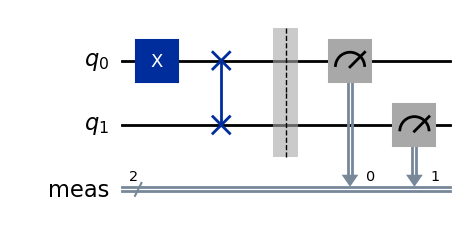

In [17]:
# Circuito con 2 qubits
swap_circuit = QuantumCircuit(2)

# Preparamos un estado distinguible
swap_circuit.x(0)        # Estado inicial |01⟩

# Aplicamos SWAP
swap_circuit.swap(0, 1)

# Medimos ambos qubits
swap_circuit.measure_all()

# Dibujamos el circuito
swap_circuit.draw('mpl')


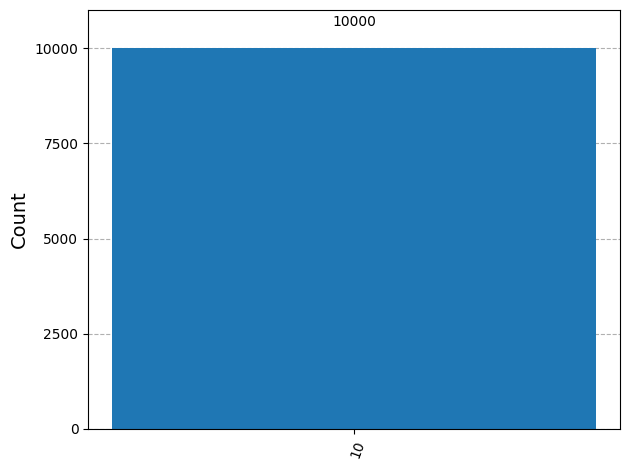

In [18]:
job = backend.run(swap_circuit, shots=10000)
result = job.result()

counts = result.get_counts()
plot_histogram(counts)


Ejercicio: Intenta aplicar una compuerta Hadamard en uno de los qubits y visualiza cómo cambia el estado al aplicar SWAP a los 2 qubits.

¿Y si generalizamos el estado de Bell para 3 qubits?

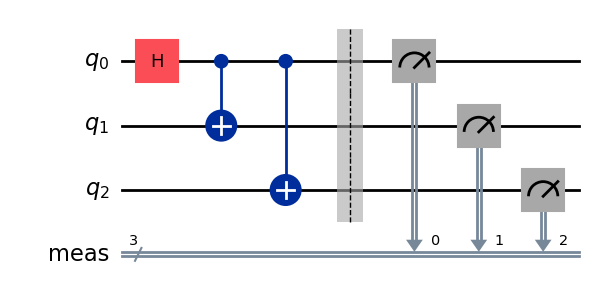

In [19]:
# Circuito de 3 qubits
ghz = QuantumCircuit(3)

# 1. Creamos superposición en el qubit 0
ghz.h(0)

# 2. Propagamos la correlación
ghz.cx(0, 1)
ghz.cx(0, 2)

# 3. Medimos todos los qubits
ghz.measure_all()

ghz.draw('mpl')


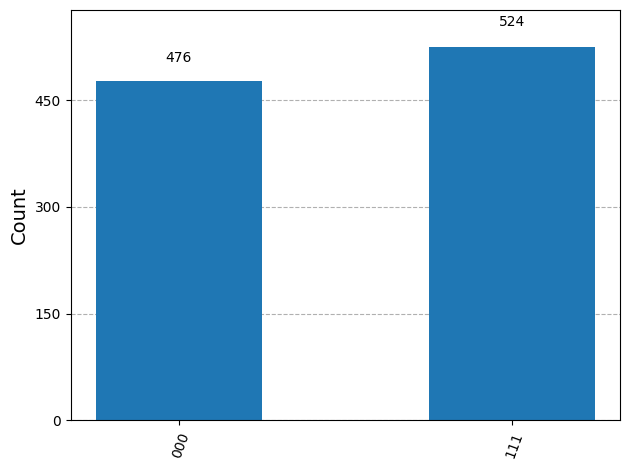

In [20]:
job = backend.run(ghz, shots=1000)
result = job.result()

counts = result.get_counts()
plot_histogram(counts)

Ahora vamos a ver los distintos tipos de compuertas que se pueden aplicar.

$S =
\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}
$

$T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{pmatrix}
$

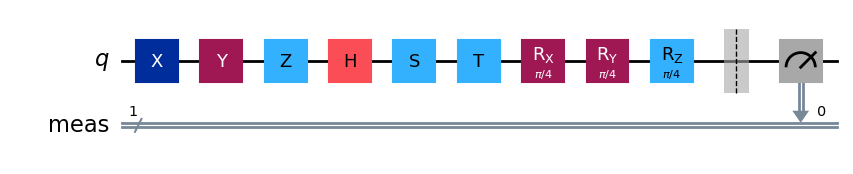

In [21]:
import numpy as np

qc = QuantumCircuit(1)

qc.x(0)
qc.y(0)
qc.z(0)
qc.h(0)
qc.s(0)
qc.t(0)

qc.rx(np.pi/4, 0)
qc.ry(np.pi/4, 0)
qc.rz(np.pi/4, 0)


qc.measure_all()
qc.draw('mpl')


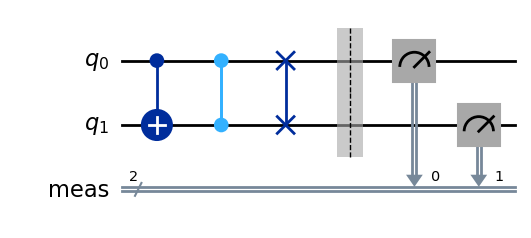

In [22]:
qc2 = QuantumCircuit(2)

qc2.cx(0, 1)
qc2.cz(0, 1)
qc2.swap(0, 1)

qc2.measure_all()
qc2.draw('mpl')


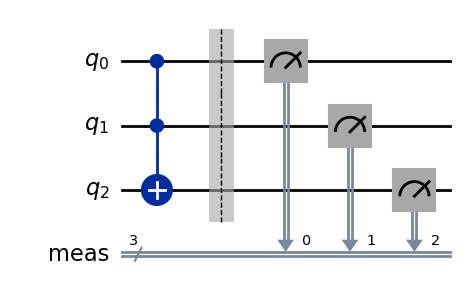

In [23]:
qc3 = QuantumCircuit(3)

qc3.ccx(0, 1, 2) #Toffoli

qc3.measure_all()
qc3.draw('mpl')


## Herramientas útiles

Además de utilizar las compuertas que Qiskit ya incluye, podemos construir nuestros propios estados y operadores. A continuación veremos dos herramientas independientes para hacerlo.

### Fabricar un estado arbitrario con NumPy

Podemos representar las amplitudes de un estado cuántico mediante un arreglo de NumPy. Para que el arreglo describa un estado válido debemos cuidar lo siguiente:

- Para un sistema de $n$ qubits, el arreglo debe tener $2^n$ entradas.
- Las entradas pueden ser números reales o complejos y representan las amplitudes de la base computacional.
- La suma de los cuadrados de sus magnitudes debe ser igual a 1. En el código podemos garantizarlo dividiendo el arreglo entre su norma.

En este ejemplo fabricaremos un estado arbitrario de dos qubits. La clase <code>Statevector</code> lo convierte en un estado cuántico de Qiskit y el método <code>initialize</code> prepara ese estado dentro de un circuito.

In [ ]:
import numpy as np  # Importamos NumPy para construir y normalizar el arreglo
from IPython.display import display  # Importamos display para mostrar el circuito
from qiskit import QuantumCircuit  # Importamos la clase para fabricar el circuito
from qiskit.quantum_info import Statevector  # Importamos la representación exacta del estado

estado_numpy = np.array([1, 1j, 2, -1], dtype=complex)  # Elegimos amplitudes arbitrarias para dos qubits
estado_numpy = estado_numpy / np.linalg.norm(estado_numpy)  # Normalizamos el arreglo para que su norma sea 1
numero_qubits = int(np.log2(len(estado_numpy)))  # Calculamos cuántos qubits corresponden al tamaño del arreglo

estado_cuantico = Statevector(estado_numpy)  # Convertimos el arreglo de NumPy en un estado cuántico de Qiskit
circuito_estado = QuantumCircuit(numero_qubits)  # Creamos un circuito con el número de qubits necesario
circuito_estado.initialize(estado_cuantico.data, range(numero_qubits))  # Preparamos el estado dentro del circuito
estado_preparado = Statevector.from_instruction(circuito_estado)  # Recuperamos el estado que preparó el circuito

print("Norma del estado:", np.linalg.norm(estado_numpy))  # Comprobamos que la norma sea igual a 1
print("Estado fabricado:", estado_cuantico)  # Mostramos el estado construido originalmente
print("Estado preparado por el circuito:", estado_preparado)  # Comprobamos el resultado de initialize
display(circuito_estado.draw("mpl"))  # Dibujamos el circuito de preparación

### Crear y utilizar nuestro propio operador

Una matriz unitaria es una matriz $U$ que satisface

$$
U^\dagger U = I.
$$

Esto significa que su adjunto hermitiano $U^\dagger$ también es su inversa. Las matrices unitarias conservan la norma del estado y, por lo tanto, la probabilidad total. Por esta razón las compuertas cuánticas deben ser unitarias.

En el siguiente ejemplo construiremos una matriz diagonal de dos qubits. El operador deja iguales las amplitudes de $|00\rangle$, $|01\rangle$ y $|10\rangle$, pero multiplica la amplitud de $|11\rangle$ por la fase $e^{i\pi/3}$. Después la convertiremos en una compuerta con <code>UnitaryGate</code> y la aplicaremos a un circuito.

In [ ]:
from qiskit.circuit.library import UnitaryGate  # Importamos la clase que convierte una matriz unitaria en compuerta

angulo_fase = np.pi / 3  # Elegimos la fase que recibirá la amplitud del estado |11>
fase = np.exp(1j * angulo_fase)  # Calculamos el número complejo que representa esa fase
operador_numpy = np.diag([1, 1, 1, fase]).astype(complex)  # Construimos nuestro operador de dos qubits
es_unitaria = np.allclose(operador_numpy.conj().T @ operador_numpy, np.eye(4))  # Verificamos que U†U sea la identidad

operador_personalizado = UnitaryGate(operador_numpy, label="U")  # Convertimos la matriz en una compuerta de Qiskit
circuito_operador = QuantumCircuit(2)  # Creamos un circuito de dos qubits
circuito_operador.h(0)  # Colocamos el primer qubit en superposición
circuito_operador.h(1)  # Colocamos el segundo qubit en superposición
circuito_operador.append(operador_personalizado, [0, 1])  # Aplicamos nuestro operador a los dos qubits
estado_final_operador = Statevector.from_instruction(circuito_operador)  # Recuperamos el estado final exacto

print("¿La matriz es unitaria?", es_unitaria)  # Mostramos el resultado de la comprobación
print("Estado final:", estado_final_operador)  # Observamos la fase aplicada a la amplitud de |11>
display(circuito_operador.draw("mpl"))  # Dibujamos el circuito con la compuerta personalizada

## Matrices de rotación en X, Y y Z

Probablemente, al trabajar con la esfera de Bloch, te preguntaste cómo podemos aplicar una rotación sobre un sistema cuántico. La respuesta es simple: Qiskit incluye operadores que rotan el estado alrededor de los ejes $X$, $Y$ y $Z$ de la esfera de Bloch.

Estas rotaciones se escriben como exponenciales de las matrices de Pauli. Para cualquiera de ellas podemos utilizar la expresión

$$
R_\sigma(\theta)=e^{-i\frac{\theta}{2}\sigma},
$$

donde $\sigma$ puede ser $X$, $Y$ o $Z$. Como las matrices de Pauli satisfacen $X^2=Y^2=Z^2=I$, la exponencial se puede separar en términos pares e impares y escribir como

$$
R_\sigma(\theta)=\cos\left(\frac{\theta}{2}\right)I-i\sin\left(\frac{\theta}{2}\right)\sigma.
$$

Al sustituir cada matriz de Pauli obtenemos las siguientes rotaciones:

- **Rotación en X:** rota el estado un ángulo $\theta$ alrededor del eje $X$.

$$
R_x(\theta)=e^{-i\frac{\theta}{2}X}=
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right) \\
-i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}.
$$

- **Rotación en Y:** rota el estado un ángulo $\theta$ alrededor del eje $Y$.

$$
R_y(\theta)=e^{-i\frac{\theta}{2}Y}=
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\
\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}.
$$

- **Rotación en Z:** rota el estado un ángulo $\theta$ alrededor del eje $Z$.

$$
R_z(\theta)=e^{-i\frac{\theta}{2}Z}=
\begin{pmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}
\end{pmatrix}.
$$

En Qiskit podemos aplicar estas operaciones con <code>qc.rx(theta, qubit)</code>, <code>qc.ry(theta, qubit)</code> y <code>qc.rz(theta, qubit)</code>, respectivamente.

### References

The explanations, code, and pedagogical presentation in this notebook were written by Benjamín Sánchez Hernández.

The following official Qiskit resources were used as references for the syntax, circuit construction workflow, simulation tools, and visualization utilities:

1. IBM Quantum Documentation. *QuantumCircuit API Reference*.  
   Used as reference for constructing quantum circuits, adding quantum and classical registers, applying gates, measuring qubits, and drawing circuits.  
   https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.QuantumCircuit

2. IBM Quantum Documentation. *Qiskit Circuit API Reference*.  
   Used as reference for the general circuit model in Qiskit and examples involving multi-qubit circuits such as GHZ-state preparation.  
   https://quantum.cloud.ibm.com/docs/api/qiskit/circuit

3. Qiskit Aer Documentation. *AerSimulator*.  
   Used as reference for classical simulation of quantum circuits and shot-based execution.  
   https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html

4. IBM Quantum Documentation. *qiskit.visualization.plot_histogram*.  
   Used as reference for visualizing measurement counts obtained from circuit simulations.  
   https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.visualization.plot_histogram

5. IBM Quantum Documentation. *Statevector API Reference*.  
   Used as reference for obtaining and inspecting statevectors from quantum circuits using `qiskit.quantum_info.Statevector`.  
   https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.Statevector

6. IBM Quantum Documentation. *Qiskit Circuit Library*.  
   Used as reference for standard gates and circuit building blocks available in Qiskit.  
   https://quantum.cloud.ibm.com/docs/api/qiskit/circuit_library